<a href="https://colab.research.google.com/github/IT21280238/Emotion-Recognition-Intensity-Prediction-/blob/Arousal-Valance-Prediction/Affect_Regression_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import shutil

folder_path = "/content/train_set"
shutil.rmtree(folder_path)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import tarfile

In [3]:
# Path to the .tar files in Google Drive
train_tar_path = '/content/drive/My Drive/AffectNet/train_set.tar'

# Extract train_set.tar
with tarfile.open(train_tar_path) as train_tar:
    train_tar.extractall('/content/train_set')
    print("Train set extracted to /content/train_set")


Train set extracted to /content/train_set


In [4]:
val_tar_path = '/content/drive/MyDrive/AffectNet/val_set.tar'

# Extract val_set.tar
with tarfile.open(val_tar_path) as val_tar:
    val_tar.extractall('/content/val_set')
    print("Validation set extracted to /content/val_set")

Validation set extracted to /content/val_set


In [5]:
import os
import numpy as np

# Define paths to the images and annotation folders
images_folder = "/content/train_set/train_set/images"
annotations_folder = "/content/train_set/train_set/annotations"

In [6]:

import os
import numpy as np

# Define paths to the images and annotation folders
images_folder_val = "/content/val_set/val_set/images"
annotations_folder_val = "/content/val_set/val_set/annotations"

In [7]:

# List all image files and annotation files
image_files = sorted([f for f in os.listdir(images_folder) if f.endswith(".jpg")])
annotation_files = sorted([f for f in os.listdir(annotations_folder) if f.endswith(".npy")])

In [8]:
# List all image files and annotation files
image_files_val = sorted([f for f in os.listdir(images_folder_val) if f.endswith(".jpg")])
annotation_files_val = sorted([f for f in os.listdir(annotations_folder_val) if f.endswith(".npy")])

In [9]:
# Group annotations by their types
annotations = {
    "aro": sorted([f for f in annotation_files if "_aro.npy" in f]),
    "val": sorted([f for f in annotation_files if "_val.npy" in f]),
    "exp": sorted([f for f in annotation_files if "_exp.npy" in f]),
    "ind": sorted([f for f in annotation_files if "_lnd.npy" in f]),
}

In [10]:
# Group annotations by their types
annotations_val = {
    "aro": sorted([f for f in annotation_files_val if "_aro.npy" in f]),
    "val": sorted([f for f in annotation_files_val if "_val.npy" in f]),
    "exp": sorted([f for f in annotation_files_val if "_exp.npy" in f]),
    "ind": sorted([f for f in annotation_files_val if "_lnd.npy" in f]),
}

In [11]:
# Align images with their respective annotations
aligned_data = []
for image_file in image_files:
    prefix = image_file.split(".")[0]  # Get the numeric prefix (e.g., '0' from '0.jpg')
    aligned_data.append({
        "image": os.path.join(images_folder, image_file),
        "aro": os.path.join(annotations_folder, f"{prefix}_aro.npy"),
        "val": os.path.join(annotations_folder, f"{prefix}_val.npy"),
        "exp": os.path.join(annotations_folder, f"{prefix}_exp.npy"),
        "ind": os.path.join(annotations_folder, f"{prefix}_lnd.npy"),
    })

In [12]:
# Align images with their respective annotations
aligned_data_val = []
for image_file in image_files_val:
    prefix = image_file.split(".")[0]  # Get the numeric prefix (e.g., '0' from '0.jpg')
    aligned_data_val.append({
        "image": os.path.join(images_folder, image_file),
        "aro": os.path.join(annotations_folder_val, f"{prefix}_aro.npy"),
        "val": os.path.join(annotations_folder_val, f"{prefix}_val.npy"),
        "exp": os.path.join(annotations_folder_val, f"{prefix}_exp.npy"),
        "ind": os.path.join(annotations_folder_val, f"{prefix}_lnd.npy"),
    })

In [13]:
import os
import numpy as np
import pandas as pd

# Example folders (replace with your actual paths)
images_folder = "/content/train_set/train_set/images"
annotations_folder = "/content/train_set/train_set/annotations"

# Prepare data for the table
aligned_data = []
for image_file in os.listdir(images_folder):
    if image_file.endswith(".jpg"):
        prefix = os.path.splitext(image_file)[0]  # Get the file name without extension
        aligned_data.append({
            "Image": os.path.join(images_folder, image_file),
            "Arousal": os.path.join(annotations_folder, f"{prefix}_aro.npy"),
            "Valence": os.path.join(annotations_folder, f"{prefix}_val.npy"),
            "Expression": os.path.join(annotations_folder, f"{prefix}_exp.npy"),
            "Index": os.path.join(annotations_folder, f"{prefix}_lnd.npy"),
        })


In [14]:
import os
import numpy as np
import pandas as pd

# Example folders (replace with your actual paths)
images_folder_val = "/content/val_set/val_set/images"
annotations_folder_val = "/content/val_set/val_set/annotations"

# Prepare data for the table
aligned_data_val = []
for image_file in os.listdir(images_folder_val):
    if image_file.endswith(".jpg"):
        prefix = os.path.splitext(image_file)[0]  # Get the file name without extension
        aligned_data_val.append({
            "Image": os.path.join(images_folder_val, image_file),
            "Arousal": os.path.join(annotations_folder_val, f"{prefix}_aro.npy"),
            "Valence": os.path.join(annotations_folder_val, f"{prefix}_val.npy"),
            "Expression": os.path.join(annotations_folder_val, f"{prefix}_exp.npy"),
            "Index": os.path.join(annotations_folder_val, f"{prefix}_lnd.npy"),
        })

In [15]:
# Convert to Pandas DataFrame
df = pd.DataFrame(aligned_data)
# Convert to Pandas DataFrame
df_val = pd.DataFrame(aligned_data_val)

In [16]:
# Load the .npy data and add it to the table
for index, row in df.iterrows():
    try:
        df.at[index, "Arousal"] = np.load(row["Arousal"]).tolist()
        df.at[index, "Valence"] = np.load(row["Valence"]).tolist()
        df.at[index, "Expression"] = np.load(row["Expression"]).tolist()
        df.at[index, "Index"] = np.load(row["Index"]).tolist()
    except FileNotFoundError as e:
        print(f"File not found: {e}")

# Display the DataFrame as a table
print(df)

                                                 Image     Arousal  \
0       /content/train_set/train_set/images/105723.jpg   0.0238095   
1       /content/train_set/train_set/images/210314.jpg    0.895491   
2        /content/train_set/train_set/images/74736.jpg           0   
3        /content/train_set/train_set/images/70906.jpg    0.239091   
4        /content/train_set/train_set/images/44445.jpg  0.00793651   
...                                                ...         ...   
287646  /content/train_set/train_set/images/108000.jpg    0.119591   
287647  /content/train_set/train_set/images/193245.jpg   -0.189633   
287648  /content/train_set/train_set/images/401475.jpg   -0.031746   
287649   /content/train_set/train_set/images/80357.jpg    0.105352   
287650  /content/train_set/train_set/images/373433.jpg   -0.140341   

           Valence Expression  \
0                0          0   
1        -0.026338          3   
2         0.571429          1   
3         0.537956         

In [17]:
# Load the .npy data and add it to the table
for index, row in df_val.iterrows():
    try:
        df_val.at[index, "Arousal"] = np.load(row["Arousal"]).tolist()
        df_val.at[index, "Valence"] = np.load(row["Valence"]).tolist()
        df_val.at[index, "Expression"] = np.load(row["Expression"]).tolist()
        df_val.at[index, "Index"] = np.load(row["Index"]).tolist()
    except FileNotFoundError as e:
        print(f"File not found: {e}")

# Display the DataFrame as a table
print(df_val)

                                         Image     Arousal     Valence  \
0     /content/val_set/val_set/images/2978.jpg    0.890223  -0.0842815   
1     /content/val_set/val_set/images/3477.jpg   -0.348432   -0.750097   
2     /content/val_set/val_set/images/4656.jpg   -0.015124  -0.0172846   
3       /content/val_set/val_set/images/91.jpg  -0.0634921   -0.563492   
4     /content/val_set/val_set/images/2986.jpg    0.662989   -0.648471   
...                                        ...         ...         ...   
3994  /content/val_set/val_set/images/4977.jpg    0.638792   -0.638792   
3995  /content/val_set/val_set/images/3656.jpg   0.0948167    0.516224   
3996  /content/val_set/val_set/images/1904.jpg    -0.39507    0.121155   
3997  /content/val_set/val_set/images/2882.jpg    0.412698   -0.730159   
3998  /content/val_set/val_set/images/2622.jpg   0.0774293    0.813008   

     Expression                                              Index  
0             3  [21.76118518518518, 92.22

In [18]:
#Save the table to a CSV file
df.to_csv("aligned_data.csv", index=False)
#Save the table to a CSV file
df_val.to_csv("aligned_data_val.csv", index=False)

In [19]:
import pandas as pd

# Ensure the Expression column contains only valid numeric values
df = df[df['Expression'].apply(lambda x: str(x).isdigit())]  # Filter out non-numeric values
df['Expression'] = df['Expression'].astype(int)  # Convert to integer

# Count the number of images per expression
expression_counts = df['Expression'].value_counts().sort_index()

# Print the results
print("Expression Counts:")
for expression, count in expression_counts.items():
    print(f"Expression {expression}: {count}")


Expression Counts:
Expression 0: 74874
Expression 1: 134415
Expression 2: 25459
Expression 3: 14090
Expression 4: 6378
Expression 5: 3803
Expression 6: 24882
Expression 7: 3750


# **Preprocessing Data for Regression**#

In [20]:
# Load dataset
df= pd.read_csv("/content/aligned_data.csv")

In [21]:
df.head()

,Image,Arousal,Valence,Expression,Index
0,/content/train_set/train_set/images/105723.jpg,0.023810,0.000000,0,"[1.104045584045582, 108.87359798361689, 5.7611..."
1,/content/train_set/train_set/images/210314.jpg,0.895491,-0.026338,3,"[58.62867579908675, 92.65903083700441, 52.2768..."
2,/content/train_set/train_set/images/74736.jpg,0.000000,0.571429,1,"[28.775935999999998, 77.5376357827476, 28.7795..."
3,/content/train_set/train_set/images/70906.jpg,0.239091,0.537956,1,"[19.93679715302491, 111.60266075388027, 20.781..."
4,/content/train_set/train_set/images/44445.jpg,0.007937,0.007937,0,"[18.064858044164037, 115.30528735632183, 25.16..."


In [22]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 18.3 MB/s eta 0:00:00


In [23]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00


In [24]:
!pip install albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.6/290.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.7/632.7 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.6/307.6 kB 20.4 MB/s eta 0:00:00


In [25]:
import os
import cv2
import numpy as np
import pandas as pd
import ast
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [26]:

import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 224

augmentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.Sharpen(alpha=(0.1, 0.3), lightness=(0.8, 1.2), p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.MotionBlur(blur_limit=3, p=0.1),
    A.GaussianBlur(blur_limit=(3, 5), p=0.1),
    A.CoarseDropout(max_holes=1, max_height=16, max_width=16, p=0.3),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.9, 1.0), ratio=(0.9, 1.1), p=0.5),
    ToTensorV2()
])

print("✅ Augmentation pipeline successfully initialized!")

✅ Augmentation pipeline successfully initialized!


<ipython-input-26-507801b2448b>:15: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=16, max_width=16, p=0.3),


In [27]:
#apply Histogram Equalization (Contrast Enhancement)
def apply_histogram_equalization(image):
    image_lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(image_lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    image_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(image_eq, cv2.COLOR_LAB2RGB)

In [28]:
import cv2
import torch
import numpy as np

IMG_SIZE = 224  # Define image size

def preprocess_image(img_path, apply_augmentation=True):
    try:
        # Load image correctly
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Could not load image: {img_path}")

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply Histogram Equalization
        image = apply_histogram_equalization(image)

        # Resize image
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        # Apply augmentations
        if apply_augmentation:
            augmented = augmentations(image=image)
            image = augmented["image"]

        # Convert to PyTorch tensor and normalize
       # image = np.transpose(image, (2, 0, 1))  # Convert to (C, H, W)

        # ✅ FIX: Proper tensor conversion
        if not isinstance(image, torch.Tensor):
            image = torch.tensor(image, dtype=torch.float32) / 255.0
        else:
            image = image.clone().detach().float() / 255.0

        return image

    except Exception as e:
        print(f"Error in preprocessing image {img_path}: {str(e)}")
        return None


Test print before function execution.
Loading image: /content/train_set/train_set/images/400898.jpg
Processed Image Shape: torch.Size([3, 224, 224])
Loading image: /content/train_set/train_set/images/79198.jpg
Processed Image Shape: torch.Size([3, 224, 224])
Loading image: /content/train_set/train_set/images/64269.jpg
Processed Image Shape: torch.Size([3, 224, 224])
Loading image: /content/train_set/train_set/images/51456.jpg
Processed Image Shape: torch.Size([3, 224, 224])
Loading image: /content/train_set/train_set/images/390348.jpg
Processed Image Shape: torch.Size([3, 224, 224])


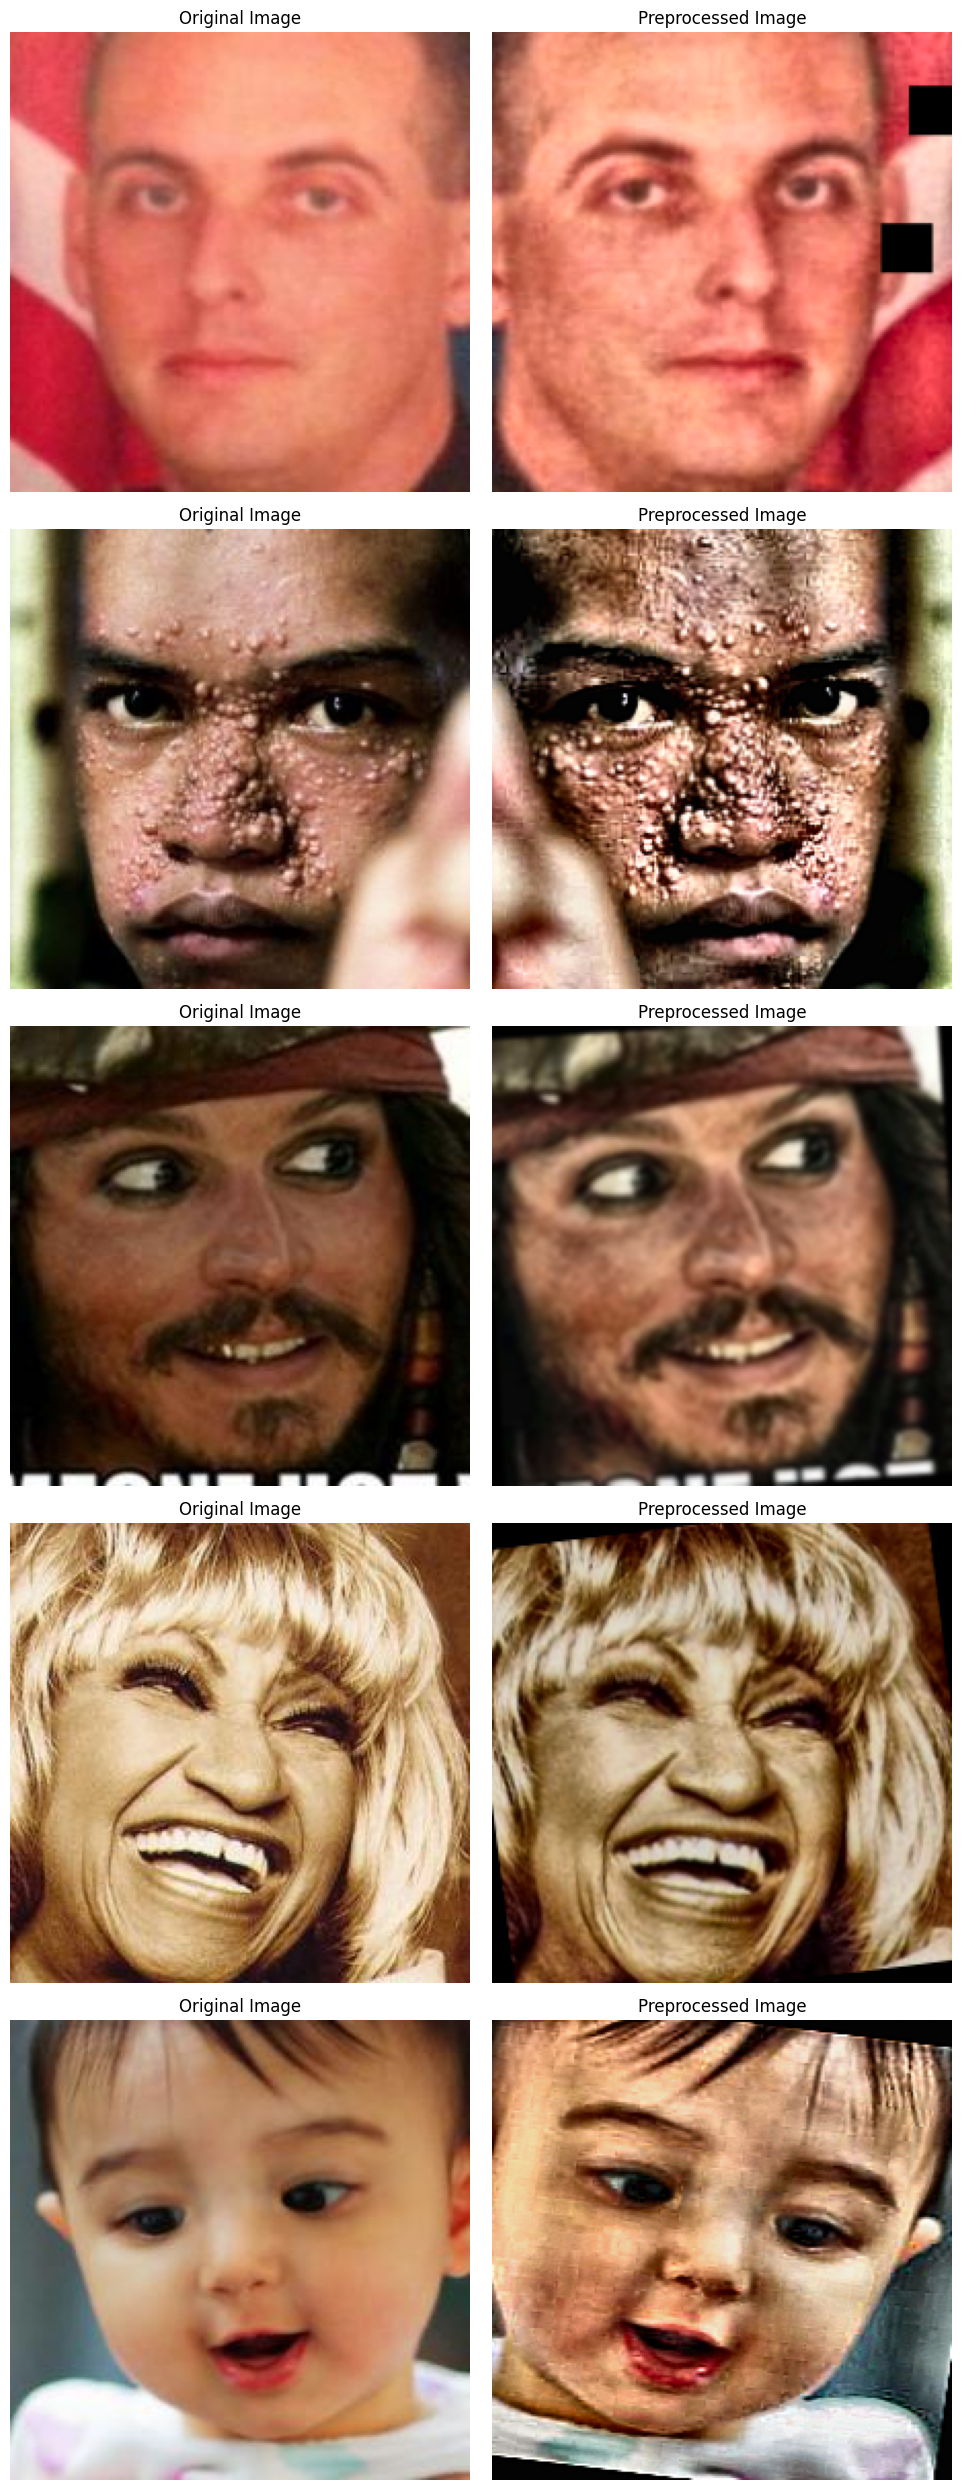

Test print after function execution.


In [29]:
def visualize_preprocessing(df, num_samples=5):
    if df.empty:
        print("Error: DataFrame is empty. No images to display.")
        return

    random_samples = df.sample(n=min(num_samples, len(df)), random_state=42)  # Avoid exceeding available images
    fig, axes = plt.subplots(len(random_samples), 2, figsize=(10, 5 * len(random_samples)))

    for i, row in enumerate(random_samples.itertuples()):
        img_path = row.Image
        print(f"Loading image: {img_path}")  # Debugging print

        # Load original image
        original_image = cv2.imread(img_path)
        if original_image is None:
            print(f"Error loading image: {img_path}")
            continue

        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

        # Process image
        processed_image = preprocess_image(img_path)
        if processed_image is None:
            print(f"Error processing image: {img_path}")
            continue

        print(f"Processed Image Shape: {processed_image.shape}")  # Debugging print

        # Convert shape (C, H, W) → (H, W, C)
        processed_image = processed_image.permute(1, 2, 0).cpu().numpy()  # (C, H, W) -> (H, W, C)

        # Ensure data is in [0,1] range
        if processed_image.max() > 1:
            processed_image = processed_image / 255.0

        # Check if shape is correct
        if processed_image.shape != (224, 224, 3):
            print(f"Invalid shape {processed_image.shape} for image data. Transposing...")
            processed_image = processed_image.transpose((1, 2, 0))  # (C, H, W) -> (H, W, C)

        # Plot original and processed images
        axes[i, 0].imshow(original_image)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(processed_image)
        axes[i, 1].set_title("Preprocessed Image")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show(block=True)

print("Test print before function execution.")
visualize_preprocessing(df, num_samples=5)
print("Test print after function execution.")


In [30]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

IMG_SIZE = 224  # Define image size
BATCH_SIZE = 5000  # Process 5000 images at a time

def preprocess_affectnet_dataset(csv_path, image_column, save_dir, output_csv, batch_size=BATCH_SIZE):
    os.makedirs(save_dir, exist_ok=True)  # Ensure save directory exists
    processed_data = []  # Store all processed data in a single list

    # Read CSV in chunks
    df_iter = pd.read_csv(csv_path, chunksize=batch_size)

    for idx, df_chunk in enumerate(df_iter):
        print(f"🔹 Processing chunk {idx+1}...")

        for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc=f"Chunk {idx+1}: Processing Images"):
            img_path = os.path.join("/content/aligned_data.csv", row[image_column])
            img_name = os.path.basename(img_path)
            save_path = os.path.join(save_dir, f"{os.path.splitext(img_name)[0]}.npy")  # Save as .npy

            processed_image = preprocess_image(img_path)

            if processed_image is not None:
                np.save(save_path, processed_image.numpy())  # Save as numpy array
                processed_data.append({
                    'Image': save_path,
                    'Arousal': row['Arousal'],
                    'Valence': row['Valence'],
                    'Expression': row['Expression'],
                    'Index': row['Index']
                })

    # Save the complete dataset as a single CSV
    final_csv_path = os.path.join(save_dir, output_csv)
    pd.DataFrame(processed_data).to_csv(final_csv_path, index=False)

    print(f"✅ Processing completed. Final dataset saved at: {final_csv_path}")
    return final_csv_path

# Run processing and save in a single CSV
final_csv = preprocess_affectnet_dataset(
    csv_path="/content/aligned_data.csv",
    image_column="Image",
    save_dir="/content/preprocessed_images",
    output_csv="reg_preprocessed_data.csv"
)


🔹 Processing chunk 1...


Chunk 1: Processing Images: 100%|██████████| 5000/5000 [01:05<00:00, 76.36it/s]


🔹 Processing chunk 2...


Chunk 2: Processing Images: 100%|██████████| 5000/5000 [00:57<00:00, 87.44it/s]


🔹 Processing chunk 3...


...

🔹 Processing chunk 57...


Chunk 57: Processing Images: 100%|██████████| 5000/5000 [03:10<00:00, 26.29it/s]


🔹 Processing chunk 58...


Chunk 58: Processing Images: 100%|██████████| 2651/2651 [01:38<00:00, 26.87it/s]


✅ Processing completed. Final dataset saved at: /content/preprocessed_images/reg_preprocessed_data.csv


In [31]:
preprocessed_csv_path = "/content/preprocessed_images/reg_preprocessed_data.csv"
df_preprocessed = pd.read_csv(preprocessed_csv_path)

# Display dataset summary
print(df_preprocessed.info())
print(df_preprocessed.head())
print("Columns in CSV:", df_preprocessed.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287651 entries, 0 to 287650
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Image       287651 non-null  object 
 1   Arousal     287651 non-null  float64
 2   Valence     287651 non-null  float64
 3   Expression  287651 non-null  int64  
 4   Index       287651 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 11.0+ MB
None
                                     Image   Arousal   Valence  Expression  \
0  /content/preprocessed_images/105723.npy  0.023810  0.000000           0   
1  /content/preprocessed_images/210314.npy  0.895491 -0.026338           3   
2   /content/preprocessed_images/74736.npy  0.000000  0.571429           1   
3   /content/preprocessed_images/70906.npy  0.239091  0.537956           1   
4   /content/preprocessed_images/44445.npy  0.007937  0.007937           0   

                                               Index  
0  [

In [32]:
import pandas as pd
# Count the number of images per expression
expression_counts = df_preprocessed['Expression'].value_counts().sort_index()

# Print the results
print("Expression Counts:")
for expression, count in expression_counts.items():
    print(f"Expression {expression}: {count}")

Expression Counts:
Expression 0: 74874
Expression 1: 134415
Expression 2: 25459
Expression 3: 14090
Expression 4: 6378
Expression 5: 3803
Expression 6: 24882
Expression 7: 3750


In [33]:
print(df_preprocessed.head())

                                     Image   Arousal   Valence  Expression  \
0  /content/preprocessed_images/105723.npy  0.023810  0.000000           0   
1  /content/preprocessed_images/210314.npy  0.895491 -0.026338           3   
2   /content/preprocessed_images/74736.npy  0.000000  0.571429           1   
3   /content/preprocessed_images/70906.npy  0.239091  0.537956           1   
4   /content/preprocessed_images/44445.npy  0.007937  0.007937           0   

                                               Index  
0  [1.104045584045582, 108.87359798361689, 5.7611...  
1  [58.62867579908675, 92.65903083700441, 52.2768...  
2  [28.775935999999998, 77.5376357827476, 28.7795...  
3  [19.93679715302491, 111.60266075388027, 20.781...  
4  [18.064858044164037, 115.30528735632183, 25.16...  


In [34]:
import pandas as pd
import os

# Ensure 'expression' column exists
if 'Expression' not in df.columns:
    raise ValueError("The dataset must contain an 'expression' column!")

# Create output directory
output_dir = "separated_datasets"
os.makedirs(output_dir, exist_ok=True)

# Separate dataset for each expression and save to CSV
for expression in sorted(df_preprocessed['Expression'].unique()):
    subset = df_preprocessed[df_preprocessed['Expression'] == expression]  # Filter by expression
    subset_path = os.path.join(output_dir, f"expression_{expression}.csv")
    subset.to_csv(subset_path, index=False)
    print(f"Saved {subset.shape[0]} samples to {subset_path}")

print("\n✅ Dataset successfully split into separate files!")


Saved 74874 samples to separated_datasets/expression_0.csv
Saved 134415 samples to separated_datasets/expression_1.csv
Saved 25459 samples to separated_datasets/expression_2.csv
Saved 14090 samples to separated_datasets/expression_3.csv
Saved 6378 samples to separated_datasets/expression_4.csv
Saved 3803 samples to separated_datasets/expression_5.csv
Saved 24882 samples to separated_datasets/expression_6.csv
Saved 3750 samples to separated_datasets/expression_7.csv

✅ Dataset successfully split into separate files!


In [35]:
# Load validation dataset (assuming CSV format)
val_df = pd.read_csv("/content/aligned_data_val.csv")

In [36]:
import pandas as pd
import os

# Ensure 'expression' column exists
if 'Expression' not in val_df.columns:
    raise ValueError("The dataset must contain an 'expression' column!")

# Create output directory
output_dir = "separated_val_datasets"
os.makedirs(output_dir, exist_ok=True)

# Separate dataset for each expression and save to CSV
for expression in sorted(val_df['Expression'].unique()):
    subset = val_df[val_df['Expression'] == expression]  # Filter by expression
    subset_path = os.path.join(output_dir, f"expression_val_{expression}.csv")
    subset.to_csv(subset_path, index=False)
    print(f"Saved {subset.shape[0]} samples to {subset_path}")

print("\n✅ Dataset successfully split into separate files!")


Saved 500 samples to separated_val_datasets/expression_val_0.csv
Saved 500 samples to separated_val_datasets/expression_val_1.csv
Saved 500 samples to separated_val_datasets/expression_val_2.csv
Saved 500 samples to separated_val_datasets/expression_val_3.csv
Saved 500 samples to separated_val_datasets/expression_val_4.csv
Saved 500 samples to separated_val_datasets/expression_val_5.csv
Saved 500 samples to separated_val_datasets/expression_val_6.csv
Saved 499 samples to separated_val_datasets/expression_val_7.csv

✅ Dataset successfully split into separate files!


**Expression 0**

In [37]:
df_0= pd.read_csv("/content/separated_datasets/expression_0.csv")

In [38]:
df_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74874 entries, 0 to 74873
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       74874 non-null  object 
 1   Arousal     74874 non-null  float64
 2   Valence     74874 non-null  float64
 3   Expression  74874 non-null  int64  
 4   Index       74874 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 2.9+ MB


In [39]:
import pandas as pd
df_0 = df_0.sample(n=25000, random_state=42)

In [40]:
df_0_val= pd.read_csv("/content/separated_val_datasets/expression_val_0.csv")

In [41]:
df_0.head()

,Image,Arousal,Valence,Expression,Index
73098,/content/preprocessed_images/20241.npy,0.000000,0.000000,0,"[32.84635514018691, 68.49283950617283, 33.1115..."
12635,/content/preprocessed_images/197266.npy,-0.431635,0.111390,0,"[29.581176470588236, 90.6495104895105, 32.4141..."
62890,/content/preprocessed_images/200669.npy,0.004839,0.038715,0,"[13.201702127659571, 69.41714285714285, 14.714..."
5924,/content/preprocessed_images/344030.npy,0.015873,0.015873,0,"[15.187878787878786, 85.04117722328856, 16.181..."
44305,/content/preprocessed_images/202362.npy,0.000000,0.000000,0,"[11.841028938906751, 75.53369472182595, 12.870..."


In [42]:
df_0_val.head()

,Image,Arousal,Valence,Expression,Index
0,/content/val_set/val_set/images/4656.jpg,-0.015124,-0.017285,0,"[25.25793103448276, 84.4447536231884, 27.16789..."
1,/content/val_set/val_set/images/652.jpg,0.000000,0.015873,0,"[29.567411300919836, 106.92785046728972, 33.64..."
2,/content/val_set/val_set/images/5380.jpg,-0.031746,0.023810,0,"[51.77023861171366, 90.64044966785897, 48.0871..."
3,/content/val_set/val_set/images/5265.jpg,-0.015312,-0.011484,0,"[23.259797979797984, 75.62635294117646, 23.176..."
4,/content/val_set/val_set/images/3905.jpg,-0.071429,-0.055556,0,"[33.79085201793722, 76.12307692307692, 31.9091..."


In [43]:
# Drop unnecessary columns
df_0 = df_0.drop(columns=["Expression", "Index"])

# Save the cleaned dataset
df_0.to_csv("df_0.csv", index=False)

# Display the first few rows of the cleaned dataset
print(df_0.head())


                                         Image   Arousal   Valence
73098   /content/preprocessed_images/20241.npy  0.000000  0.000000
12635  /content/preprocessed_images/197266.npy -0.431635  0.111390
62890  /content/preprocessed_images/200669.npy  0.004839  0.038715
5924   /content/preprocessed_images/344030.npy  0.015873  0.015873
44305  /content/preprocessed_images/202362.npy  0.000000  0.000000


In [44]:
# Drop unnecessary columns
df_0_val = df_0_val.drop(columns=["Expression", "Index"])

# Save the cleaned dataset
df_0_val.to_csv("df_0_val.csv", index=False)

# Display the first few rows of the cleaned dataset
print(df_0_val.head())


                                      Image   Arousal   Valence
0  /content/val_set/val_set/images/4656.jpg -0.015124 -0.017285
1   /content/val_set/val_set/images/652.jpg  0.000000  0.015873
2  /content/val_set/val_set/images/5380.jpg -0.031746  0.023810
3  /content/val_set/val_set/images/5265.jpg -0.015312 -0.011484
4  /content/val_set/val_set/images/3905.jpg -0.071429 -0.055556


In [45]:
df_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 73098 to 22062
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Image    25000 non-null  object 
 1   Arousal  25000 non-null  float64
 2   Valence  25000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 781.2+ KB


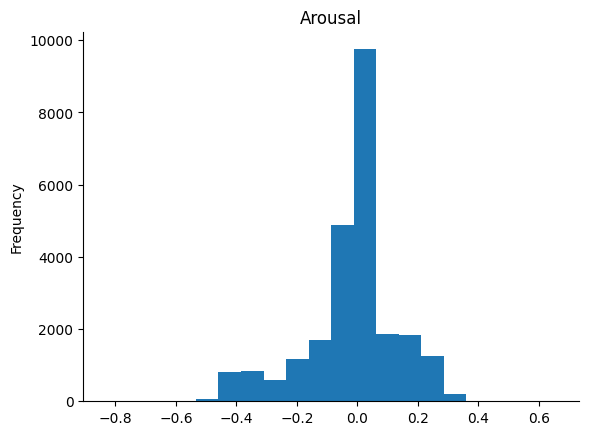

In [46]:
from matplotlib import pyplot as plt
df_0['Arousal'].plot(kind='hist', bins=20, title='Arousal')
plt.gca().spines[['top', 'right',]].set_visible(False)

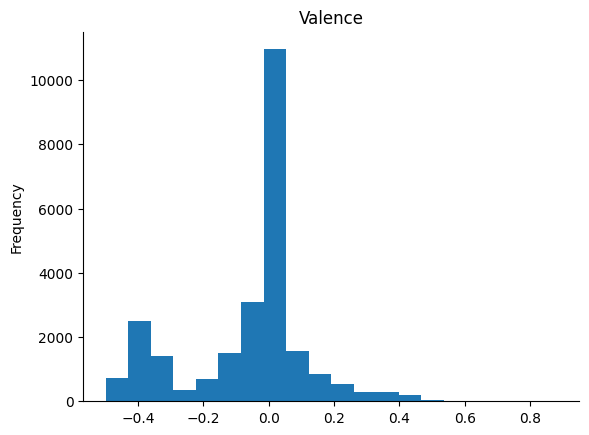

In [47]:
df_0['Valence'].plot(kind='hist', bins=20, title='Valence')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [48]:
df_0.head()

,Image,Arousal,Valence
73098,/content/preprocessed_images/20241.npy,0.000000,0.000000
12635,/content/preprocessed_images/197266.npy,-0.431635,0.111390
62890,/content/preprocessed_images/200669.npy,0.004839,0.038715
5924,/content/preprocessed_images/344030.npy,0.015873,0.015873
44305,/content/preprocessed_images/202362.npy,0.000000,0.000000


from matplotlib import pyplot as plt
_df_0['Arousal'].plot(kind='hist', bins=20, title='Arousal')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Valence'].plot(kind='hist', bins=20, title='Valence')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('Image').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='Arousal', y='Valence', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_5['Valence'].plot(kind='line', figsize=(8, 4), title='Valence')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_6['Image'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_6, x='Arousal', y='Image', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_7['Image'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_7, x='Valence', y='Image', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

# **Regression - Neutral**

In [49]:
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

def define_mtl_va_model(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # Shared Feature Extraction
    x = Conv2D(64, (7,7), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    x = Conv2D(256, (1,1), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)

    x = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)

    # Task-Specific Layers
    valence_branch = Dense(256, activation='relu', kernel_initializer='he_uniform',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    valence_branch = BatchNormalization()(valence_branch)
    valence_branch = Dropout(0.5)(valence_branch)
    valence_output = Dense(1, activation='linear', name='valence')(valence_branch)

    arousal_branch = Dense(256, activation='relu', kernel_initializer='he_uniform',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    arousal_branch = BatchNormalization()(arousal_branch)
    arousal_branch = Dropout(0.5)(arousal_branch)
    arousal_output = Dense(1, activation='linear', name='arousal')(arousal_branch)

    # Define Model with Two Outputs
    model = Model(inputs=inputs, outputs=[valence_output, arousal_output])

    return model


In [50]:
model = define_mtl_va_model(input_shape=(224, 224, 3))

In [51]:
import cv2
import numpy as np
import os

# Convert JPG images to NPY format
for img_path in df_0_val["Image"]:
    img = cv2.imread(img_path)  # Read image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (224, 224))  # Resize
    img = img.astype(np.float32) / 255.0  # Normalize

    npy_path = img_path.replace(".jpg", ".npy")  # Save as .npy
    np.save(npy_path, img)

    # Update dataset path to the new .npy file
    df_0_val["Image"] = df_0_val["Image"].replace(img_path, npy_path)

# Save the updated CSV file
df_0_val.to_csv("df_1_val_updated.csv", index=False)


In [52]:
df_0_val.head()

,Image,Arousal,Valence
0,/content/val_set/val_set/images/4656.npy,-0.015124,-0.017285
1,/content/val_set/val_set/images/652.npy,0.000000,0.015873
2,/content/val_set/val_set/images/5380.npy,-0.031746,0.023810
3,/content/val_set/val_set/images/5265.npy,-0.015312,-0.011484
4,/content/val_set/val_set/images/3905.npy,-0.071429,-0.055556


In [53]:
def load_and_preprocess(img_path, valence, arousal):
    def _load_npy(path):
        path = path.numpy().decode("utf-8")  # Convert Tensor to string
        img = np.load(path)  # Load .npy image
        img = cv2.resize(img, (224, 224))  # Resize

        # Ensure image has 3 channels
        if len(img.shape) == 2:  # Grayscale image
            img = np.stack([img] * 3, axis=-1)  # Convert to 3-channel format
        elif img.shape[-1] != 3:  # Incorrect channel count
            img = img[:, :, :3]  # Keep only first 3 channels if needed

        img = img / 255.0  # Normalize
        return img.astype(np.float32)

    img = tf.py_function(func=_load_npy, inp=[img_path], Tout=tf.float32)

    # 🚀 Explicitly set shape to avoid TensorFlow shape errors
    img.set_shape((224, 224, 3))

    return img, {"valence": tf.reshape(valence, [1]), "arousal": tf.reshape(arousal, [1])}


In [54]:
# Convert DataFrame columns to a list
image_paths = df_0["Image"].tolist()
valence_values = df_0["Valence"].tolist()
arousal_values = df_0["Arousal"].tolist()

In [55]:
# Create Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((image_paths, valence_values, arousal_values))
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [56]:
# Extract validation image paths and labels
val_image_paths = df_0_val["Image"].values  # Paths to validation .npy files
val_valence_labels = df_0_val["Valence"].values.astype(np.float32)
val_arousal_labels = df_0_val["Arousal"].values.astype(np.float32)

In [57]:
val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_valence_labels, val_arousal_labels))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [58]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss={'valence': 'mse', 'arousal': 'mse'},
              metrics={'valence': 'mae', 'arousal': 'mae'})

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4405s 1s/step - arousal_loss: 1.4958 - arousal_mae: 0.9300 - loss: 6.0834 - valence_loss: 1.3685 - valence_mae: 0.8919 - val_arousal_loss: 0.1701 - val_arousal_mae: 0.2974 - val_loss: 3.3808 - val_valence_loss: 0.0888 - val_valence_mae: 0.2331
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4365s 1s/step - arousal_loss: 0.5435 - arousal_mae: 0.5657 - loss: 4.0146 - valence_loss: 0.5318 - valence_mae: 0.5500 - val_arousal_loss: 0.0306 - val_arousal_mae: 0.1400 - val_loss: 2.3131 - val_valence_loss: 0.0401 - val_valence_mae: 0.1569
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4378s 1s/step - arousal_loss: 0.1264 - arousal_mae: 0.2719 - loss: 2.2073 - valence_loss: 0.1299 - valence_mae: 0.2767 - val_arousal_loss: 0.0151 - val_arousal_mae: 0.0777 - val_loss: 1.0504 - val_valence_loss: 0.0208 - val_valence_mae: 0.0969
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4341s 1s/step - arousal_loss: 0.0276 - arousal_mae: 0.1217 - loss: 0.8088 - valence_loss: 0.0393 - v

In [ ]:
# Alternatively, save in HDF5 format
model.save('emotion0_intensity_model.h5')  # Saves the model in HDF5 format

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define path inside Google Drive
model_path = "/content/drive/My Drive/emotion0_intensity_model"

# OR Save in HDF5 format
model.save(model_path + ".h5")


In [ ]:
import matplotlib.pyplot as plt

# Extract loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot training vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [ ]:
# Extract metrics
train_valence_mae = history.history['valence_mae']
val_valence_mae = history.history['val_valence_mae']
train_arousal_mae = history.history['arousal_mae']
val_arousal_mae = history.history['val_arousal_mae']

# Plot valence MAE
plt.figure(figsize=(8, 5))
plt.plot(train_valence_mae, label='Training Valence MAE')
plt.plot(val_valence_mae, label='Validation Valence MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Valence MAE: Training vs Validation')
plt.legend()
plt.show()

# Plot arousal MAE
plt.figure(figsize=(8, 5))
plt.plot(train_arousal_mae, label='Training Arousal MAE')
plt.plot(val_arousal_mae, label='Validation Arousal MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Arousal MAE: Training vs Validation')
plt.legend()
plt.show()


In [ ]:
# Print the keys available in history
print(history.history.keys())

# Print the loss and metrics for first few epochs
print(history.history['loss'])  # Training loss
print(history.history['val_loss'])  # Validation loss

print(history.history['valence_mae'])  # Training MAE for valence
print(history.history['val_valence_mae'])  # Validation MAE for valence


In [ ]:
import cv2
import numpy as np

# Load the image
image_path = "/content/happy.jpg"  # Replace with your test image path
image = cv2.imread(image_path)  # Read the image using OpenCV
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Resize the image to match the model's expected input shape
img_size = (224, 224)  # Change this based on your model input size
image = cv2.resize(image, img_size)

# Normalize pixel values to [0, 1]
image = image.astype("float32") / 255.0

# Expand dimensions to match batch format
image = np.expand_dims(image, axis=0)  # Shape: (1, 224, 224, 3)


In [ ]:
# Perform inference
predictions = model.predict(image)

# Assuming the model outputs valence & arousal separately
valence_pred = predictions[0][0]  # Extract valence prediction
arousal_pred = predictions[1][0]  # Extract arousal prediction

# Print results
print(f"Predicted Valence: {valence_pred[0]:.2f}")  # Access the scalar value
print(f"Predicted Arousal: {arousal_pred[0]:.2f}")  # Access the scalar value


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Valence: 0.28
Predicted Arousal: 0.75
